# CMSE 801 - Day 18
## Autoregression

### Nov 9, 2022

## General Course Announcements

* Homework #4 is due Monday Nov 14 at 11:59 p.m. 
* Project's deadline Sunday Dec 4 at 11:59 p.m.
* Homework #5 will be released today and is due Wednesday Nov 30 at 11:59 p.m. 
* Homework #5 is extra credit, you can gain up to 5% of the final grade

## Questions/comments from Day 18 PCA

* Could you explain the last question? - the relationship between actual value and predicted value from polynomials of different degrees
* If data has auto correlation, does it mean it has some kind of correlation with time?
* Is there a more direct way to predict a lot more points with autoregression other than using a loop?
* I got a value error in the last part, is that possible to you to go through the last part of the Pre-Class!!?
* So if we have data with autocorrelation, we can predict only one data point each time?

* I'm curious as to why I can just use 'plot_lag' and I do not have to type 'pd.' before it.?
* when we compute a mask then the result is a copy of the original data but with false and true instead of the values?
* Not right now! I am enjoying the process of learning these concepts even though sometimes I bang my head against the wall.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
test_input = np.array([0.4,0.9144,0.298219,0.797373,0.615578,0.901605,0.337999,0.852509,0.479059,0.950829,0.178129,0.557781,0.93978,0.215622,0.644382,0.873076,0.422203,0.92944,0.249864,0.714115,0.777829,0.65841,0.856893,0.46721,0.948404,0.186439,0.577899,0.92938,0.250062,0.714492,0.777214,0.659711,0.855316,0.47149,0.949403,0.18302,0.569685,0.933999,0.234868,0.684676,0.822559,0.556092,0.940513,0.213164,0.639032,0.878853,0.405653,0.918586,0.284933,0.776274,0.661694,0.852888,0.478041,0.950663,0.1787,0.559181,0.939156,0.217711,0.648893,0.868036,0.436433,0.937105,0.224559,0.663444,0.85072,0.483854,0.951507,0.1758,0.552047,0.942179,0.207559,0.626663,0.891374,0.368907,0.887024,0.381809,0.899277,0.3451,0.861083,0.455748,0.945039,0.197892,0.604765,0.910683,0.309905,0.814821,0.574883,0.931136,0.244305,0.703403,0.79487,0.621227,0.896508,0.353496,0.870724,0.428867,0.933222,0.237435,0.689838,0.815194,0.573987,0.931644,0.242636,0.700139,0.799888,0.609856,0.906519,0.322867,0.832957,0.530123,0.949043,0.184254,0.572659,0.932386,0.240192,0.695325,0.807142,0.59308,0.919491,0.282045,0.771508,0.67164,0.840256,0.511401,0.952005,0.174085,0.5478,0.943795,0.202106,0.614398,0.902639,0.334831,0.84856,0.489608,0.952089,0.173797,0.547083,0.944054,0.20123,0.612406,0.904361,0.329537,0.84179,0.507415,0.952291,0.173101,0.545352,0.944664,0.199165,0.607688,0.908317,0.317287,0.825307,0.549309,0.943237,0.203993,0.618667,0.898848,0.346405,0.862616,0.451521,0.943546,0.202949,0.616307,0.90096,0.339969,0.854926,0.472545,0.949628,0.18225,0.567823,0.934974,0.231639,0.678112,0.831631,0.533478,0.94823,0.187033,0.579317,0.92853,0.252838,0.719751,0.768513,0.677801,0.832054,0.532411,0.948498,0.186118,0.577131,0.929833,0.248577,0.711656,0.781819,0.649903,0.866885,0.439656,0.938626,0.219483,0.652693,0.86367,0.448606,0.942436,0.206692,0.624728,0.893227,0.363369,0.881375,0.398349,0.913131,0.302219,0.803463,0.601639,0.913141,0.302188,0.803416,0.601746,0.913058,0.30245,0.803811,0.600833,0.913763,0.30023,0.80045,0.60857,0.907589,0.319548,0.828435,0.541516,0.945933,0.194858,0.597744,0.9161,0.29284,0.788993,0.6343,0.883781,0.391333,0.907509,0.319796,0.828776,0.540662,0.9462,0.193949,0.595627,0.917659,0.287886,0.78108,0.651487,0.865066,0.444728,0.94086,0.211996,0.636475,0.881537,0.397878,0.912766,0.30337,0.805192,0.597627,0.916187,0.292565,0.788559,0.635256,0.8828,0.3942,0.909852,0.312502,0.818557,0.565867,0.935971,0.228332,0.671308,0.84069,0.510275,0.952098,0.173765,0.547004,0.944082,0.201134,0.612187,0.904548,0.32896,0.84104,0.509365,0.952166,0.173531,0.546421,0.94429,0.200432,0.610586,0.905907,0.324764,0.835503,0.523637,0.950371,0.179701,0.561627,0.93803,0.221474,0.656932,0.858668,0.462371,0.947105,0.190869,0.58841,0.92272,0.271683,0.753889,0.706908,0.78939,0.633425,0.884673,0.388721,0.90532,0.326576,0.83791,0.517461,0.951338,0.176379,0.553476,0.941604,0.209495,0.630962,0.887155,0.381423,0.89893,0.346158,0.862327,0.45232,0.943838,0.201959,0.614063,0.902931,0.333934,0.847428,0.492609,0.952292,0.173096,0.54534,0.944668,0.199151,0.607657,0.908342,0.317207,0.825196,0.549583,0.943133,0.204342,0.619454,0.898135,0.348573,0.865136,0.444535,0.940779,0.212269,0.637074,0.880913,0.39969,0.914163,0.298966,0.798519,0.612976,0.90387,0.331046,0.843741,0.502317,0.95248,0.172449,0.543727,0.945215,0.197295,0.603389,0.911774,0.306485,0.809823,0.586777,0.92381,0.268167,0.747726,0.718687,0.77029,0.674154,0.836944,0.519945,0.950984,0.177596,0.556472,0.94035,0.213712,0.640229,0.87758,0.409321,0.921172,0.276661,0.762456,0.690054,0.81488,0.57474,0.931217,0.244037,0.702881,0.795678,0.619408,0.898176,0.348448,0.864992,0.444935,0.940947,0.211704,0.635834,0.882202,0.39594,0.911244,0.308147,0.812264,0.580992,0.927508,0.256174,0.725991,0.757916,0.699057,0.801534,0.606083,0.909624,0.313215,0.819574,0.563395,0.937188,0.224282,0.662862,0.851443,0.481918,0.951254,0.176668,0.554189,0.941312,0.210478,0.633134,0.884969,0.387854,0.904583,0.328851,0.840898,0.509735,0.952139,0.173623,0.546652,0.944208,0.200708,0.611217,0.905373,0.326413,0.837695,0.518015,0.951263,0.176636,0.554111,0.941344,0.21037,0.632896,0.88521,0.387146,0.903976,0.330721,0.843323,0.503412,0.952456,0.172532,0.543933,0.945146,0.197528,0.603926,0.91135,0.307815,0.811778,0.582148,0.926789,0.258512,0.730315,0.750398,0.713616,0.778643,0.656684,0.858965,0.461559,0.94687,0.191671,0.590296,0.921436,0.275813,0.761009,0.69294,0.810669,0.584777,0.925117,0.26394,0.740189,0.732697,0.746196,0.721567,0.76546])

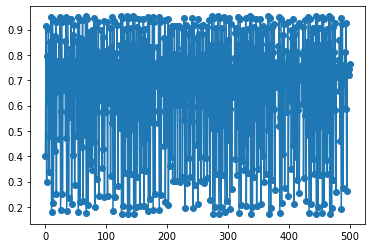

In [2]:
plt.plot(test_input,marker='o')

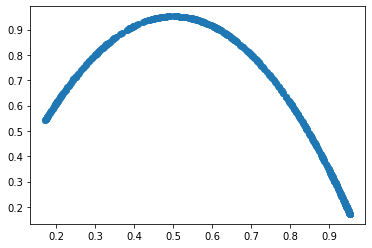

In [3]:
plt.scatter(test_input[0:len(test_input)-1],test_input[1:len(test_input)])

In [4]:
print(pd.Series(test_input))

0      0.400000
1      0.914400
2      0.298219
3      0.797373
4      0.615578
         ...   
496    0.740189
497    0.732697
498    0.746196
499    0.721567
500    0.765460
Length: 501, dtype: float64


<AxesSubplot:xlabel='y(t)', ylabel='y(t + 1)'>

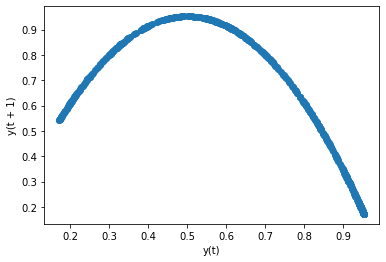

In [5]:
from pandas.plotting import lag_plot
lag_plot(pd.Series(test_input))

In [6]:
trump = pd.read_csv("trump_ratings_first500.csv")
ipsos = trump['pollster'] == 'Ipsos' 
trump = trump[ipsos] 

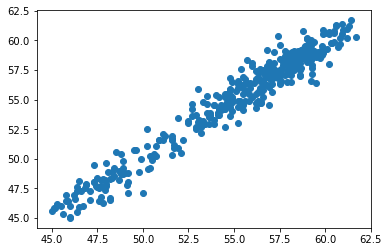

In [7]:
plt.scatter(trump['disapprove'].iloc[0:399], trump['disapprove'].iloc[1:400])
pfit = np.polyfit(trump['disapprove'].iloc[0:399], trump['disapprove'].iloc[1:400], 1)
autoreg = np.poly1d(pfit)

In [8]:
starting_date = trump['datenumber'].iloc[400]
starting_value = trump['disapprove'].iloc[400]
num_predictions = 100
forecast_dates = []
forecast_values = []
for i in range(num_predictions):
    date = starting_date + 1
    new_value =  autoreg(starting_value) # pfit[0] * starting_value + pfit[1]
    forecast_dates.append(date)
    forecast_values.append(new_value)
    starting_date = date
    starting_value = new_value

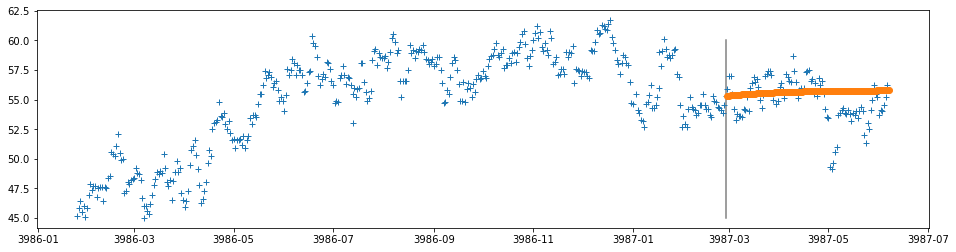

In [9]:
plt.figure(2, figsize=(16,4))
starting_date = trump['datenumber'].iloc[400]
plt.plot([starting_date,starting_date], [45,60],color = 'grey')
plt.plot_date(trump['datenumber'],trump['disapprove'], marker = '+')
plt.plot_date(forecast_dates, forecast_values)